# !pip install torch_geometric --quiet
!pip install optuna --quietGraph Neural Network — Karate Club Node Classification

In this notebook, we build a simple Graph Convolutional Network (GCN) to classify nodes in the Karate Club dataset. The dataset represents a social network of 34 people, and our goal is to predict which community each person belongs to.

In [1]:
!pip install torch_geometric --quiet
!pip install optuna --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00


## 1. Imports

In [2]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch.nn import Linear
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv

## 2. Load the Dataset

The Karate Club dataset contains 34 nodes (people) and 156 edges (friendships). Each node has a label indicating which of the 4 communities it belongs to.

In [3]:
dataset = KarateClub()
data = dataset[0]

print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.edge_index.shape[1]}")
print(f"Features per node: {data.num_features}")
print(f"Number of classes: {dataset.num_classes}")

Nodes: 34
Edges: 156
Features per node: 34
Number of classes: 4


## 3. Assign Labels

We randomly assign each node to one of 4 countries (communities) to simulate a classification task.

In [4]:
num_countries = 4
np.random.seed(42)
countries = torch.tensor(np.random.choice(num_countries, data.num_nodes))
data.y = countries

print(f"Labels: {data.y}")

Labels: tensor([2, 3, 0, 2, 2, 3, 0, 0, 2, 1, 2, 2, 2, 2, 3, 0, 3, 3, 3, 2, 1, 0, 1, 3,
        3, 1, 1, 1, 3, 3, 0, 0, 3, 1])


## 4. Visualize the Graph

Each color represents a different community. Node 0 (instructor) and Node 33 (club president) are the two most connected nodes.

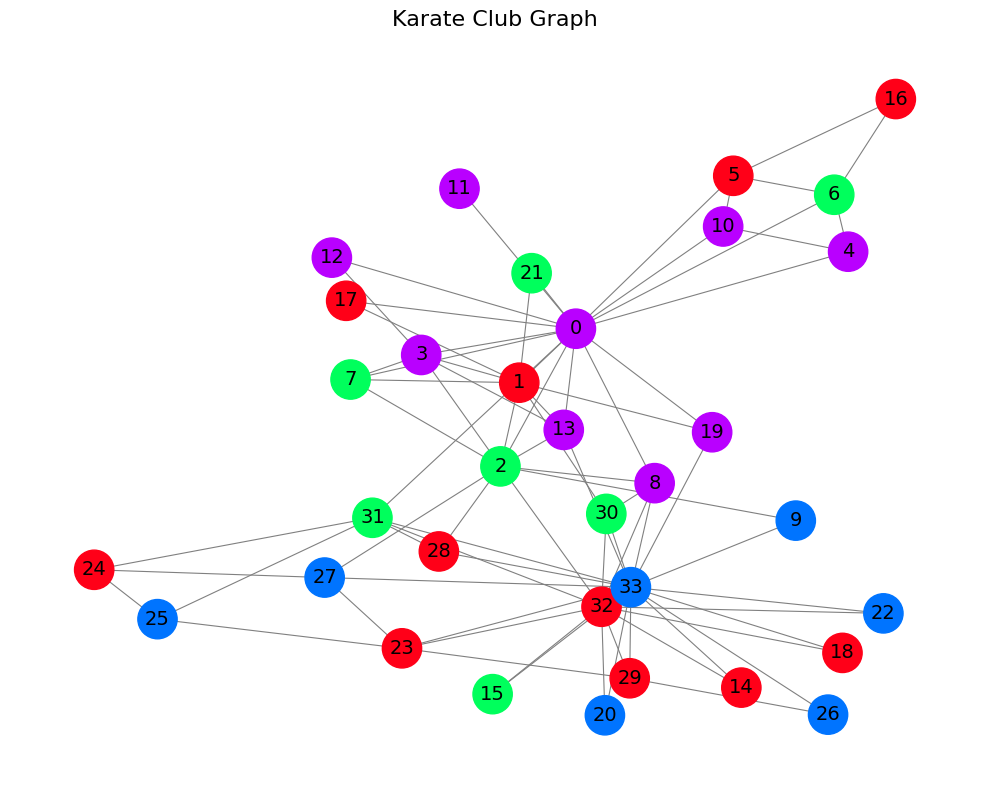

In [5]:
G = to_networkx(data, to_undirected=True)

plt.figure(figsize=(10, 8))
plt.axis('off')
nx.draw_networkx(G,
                 pos=nx.spring_layout(G, seed=0),
                 with_labels=True,
                 node_size=800,
                 node_color=data.y,
                 cmap='hsv',
                 vmin=-2,
                 vmax=3,
                 width=0.8,
                 edge_color='grey',
                 font_size=14)
plt.title("Karate Club Graph", fontsize=16)
plt.tight_layout()
plt.show()

## 5. Model Architecture

Our GCN has two layers:
- **GCNConv**: takes node features and aggregates information from neighbors, outputting a 3-dimensional embedding
- **Linear**: maps the 3-dimensional embedding to 4 class scores

In [6]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn = GCNConv(dataset.num_features, 3)
        self.out = Linear(3, num_countries)

    def forward(self, x, edge_index):
        h = self.gcn(x, edge_index).relu()
        z = self.out(h)
        return h, z

model = GCN()
print(model)

GCN(
  (gcn): GCNConv(34, 3)
  (out): Linear(in_features=3, out_features=4, bias=True)
)


## 6. Training

We use Cross-Entropy Loss and Adam optimizer. The model is trained for 200 epochs on all nodes.

In [7]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)

def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)

embeddings = []
losses = []
accuracies = []
outputs = []

for epoch in range(201):
    optimizer.zero_grad()
    h, z = model(data.x, data.edge_index)
    loss = criterion(z, data.y)
    acc = accuracy(z.argmax(dim=1), data.y)
    loss.backward()
    optimizer.step()

    embeddings.append(h.detach())
    losses.append(loss.detach())
    accuracies.append(acc.detach())
    outputs.append(z.argmax(dim=1).detach())

    if epoch % 10 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%")

Epoch   0 | Loss: 1.46 | Acc: 20.59%
Epoch  10 | Loss: 1.32 | Acc: 35.29%
Epoch  20 | Loss: 1.16 | Acc: 50.00%
Epoch  30 | Loss: 1.01 | Acc: 52.94%
Epoch  40 | Loss: 0.86 | Acc: 67.65%
Epoch  50 | Loss: 0.73 | Acc: 67.65%
Epoch  60 | Loss: 0.62 | Acc: 79.41%
Epoch  70 | Loss: 0.52 | Acc: 82.35%
Epoch  80 | Loss: 0.43 | Acc: 88.24%
Epoch  90 | Loss: 0.35 | Acc: 94.12%
Epoch 100 | Loss: 0.28 | Acc: 100.00%
Epoch 110 | Loss: 0.23 | Acc: 100.00%
Epoch 120 | Loss: 0.18 | Acc: 100.00%
Epoch 130 | Loss: 0.15 | Acc: 100.00%
Epoch 140 | Loss: 0.12 | Acc: 100.00%
Epoch 150 | Loss: 0.10 | Acc: 100.00%
Epoch 160 | Loss: 0.08 | Acc: 100.00%
Epoch 170 | Loss: 0.07 | Acc: 100.00%
Epoch 180 | Loss: 0.06 | Acc: 100.00%
Epoch 190 | Loss: 0.05 | Acc: 100.00%
Epoch 200 | Loss: 0.05 | Acc: 100.00%


## 7. Training Loss & Accuracy

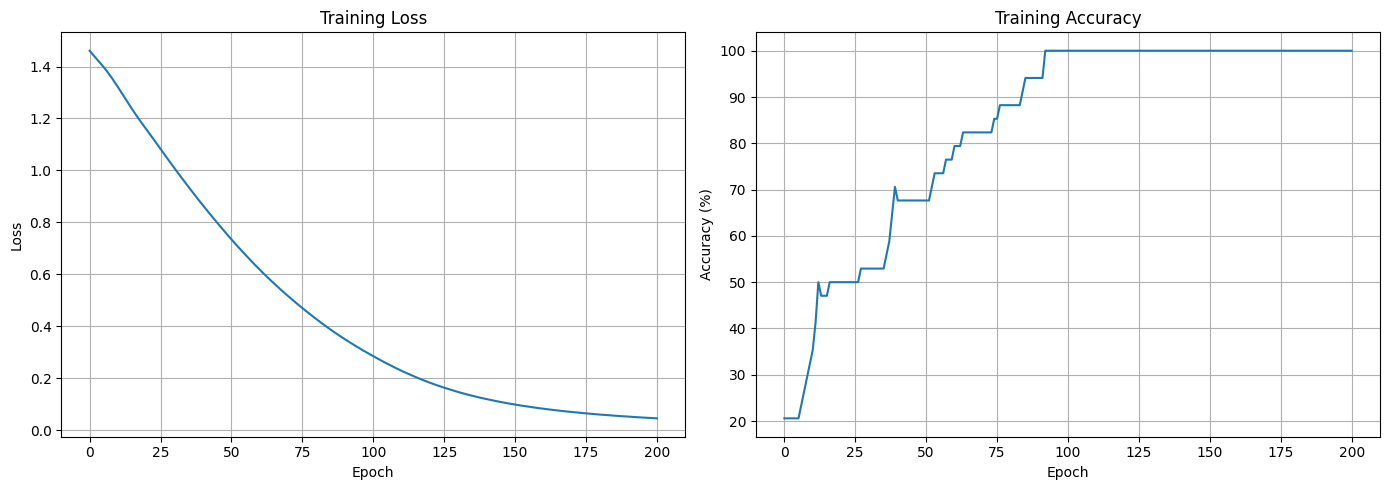

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot([a * 100 for a in accuracies])
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.grid(True)

plt.tight_layout()
plt.show()

## 8. Graph Animation — Learning Process

Watch how the model learns to classify nodes over 200 epochs. Each color represents a predicted community.

In [9]:
from IPython.display import HTML
from matplotlib import animation

plt.rcParams['animation.bitrate'] = 3000

def animate(i):
    G = to_networkx(data, to_undirected=True)
    nx.draw_networkx(G,
                     pos=nx.spring_layout(G, seed=0),
                     with_labels=True,
                     node_size=800,
                     node_color=outputs[i].numpy(),
                     cmap='hsv',
                     vmin=-2,
                     vmax=3,
                     width=0.8,
                     edge_color='grey',
                     font_size=14)
    plt.title(f"Epoch {i} | Loss: {losses[i].item():.2f} | Acc: {accuracies[i].item()*100:.2f}%",
              fontsize=16, pad=20)

fig = plt.figure(figsize=(10, 8))
plt.axis('off')
anim = animation.FuncAnimation(fig, animate, np.arange(0, 200, 10), interval=500, repeat=False)
html = HTML(anim.to_html5_video())
plt.close()
display(html)

## 9. Final Node Embeddings (3D)

After training, each node is represented as a point in 3D space. Nodes with the same color belong to the same predicted community — notice how they cluster together.

In [10]:
print(f'Final embeddings = {h.shape}')

def animate_3d(i):
    embed = embeddings[i].detach().cpu().numpy()
    ax.clear()
    ax.scatter(embed[:,0], embed[:,1], embed[:,2],
               s=200, c=data.y, cmap='hsv', vmin=-2, vmax=3)
    plt.title(f'Epoch {i} | Loss: {losses[i].item():.2f} | Acc: {accuracies[i].item()*100:.2f}%',
              fontsize=18, pad=40)

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')
plt.axis('off')
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
anim = animation.FuncAnimation(fig, animate_3d, np.arange(0,200,10), interval=800, repeat=False)
html = HTML(anim.to_html5_video())
plt.close()
display(html)

Final embeddings = torch.Size([34, 3])


## 8.1 Graph Animation — GIF

![Graph Animation](karate_club_animation.gif)

In [11]:
from matplotlib.animation import PillowWriter

fig = plt.figure(figsize=(10, 8))
plt.axis('off')
anim = animation.FuncAnimation(fig, animate, np.arange(0, 200, 10), interval=500, repeat=False)
writer = PillowWriter(fps=2)
anim.save("karate_club_animation.gif", writer=writer)
plt.close()
print("Saved!")

Saved!


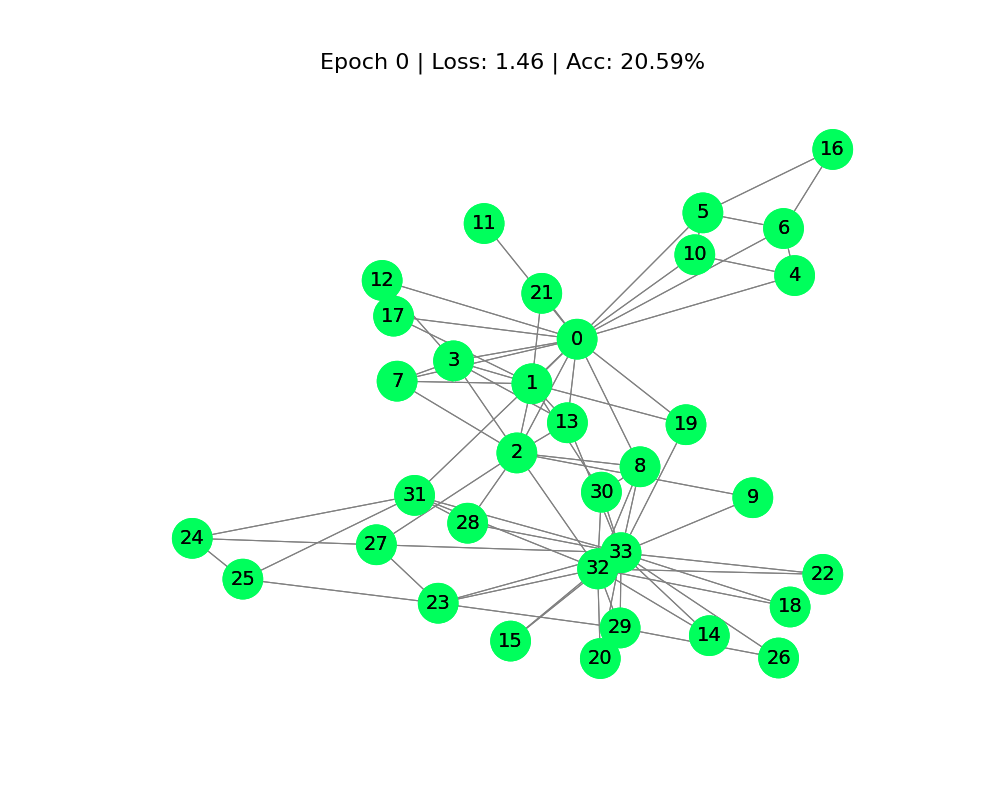

In [12]:
from IPython.display import Image
Image("karate_club_animation.gif")

## 9.1 Final Node Embeddings — GIF

![3D Embeddings](embeddings_3d_animation.gif)

In [13]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
plt.axis('off')
anim = animation.FuncAnimation(fig, animate_3d, np.arange(0, 200, 10), interval=800, repeat=False)
writer = PillowWriter(fps=1)
anim.save("embeddings_3d_animation.gif", writer=writer)
plt.close()
print("Saved!")

Saved!


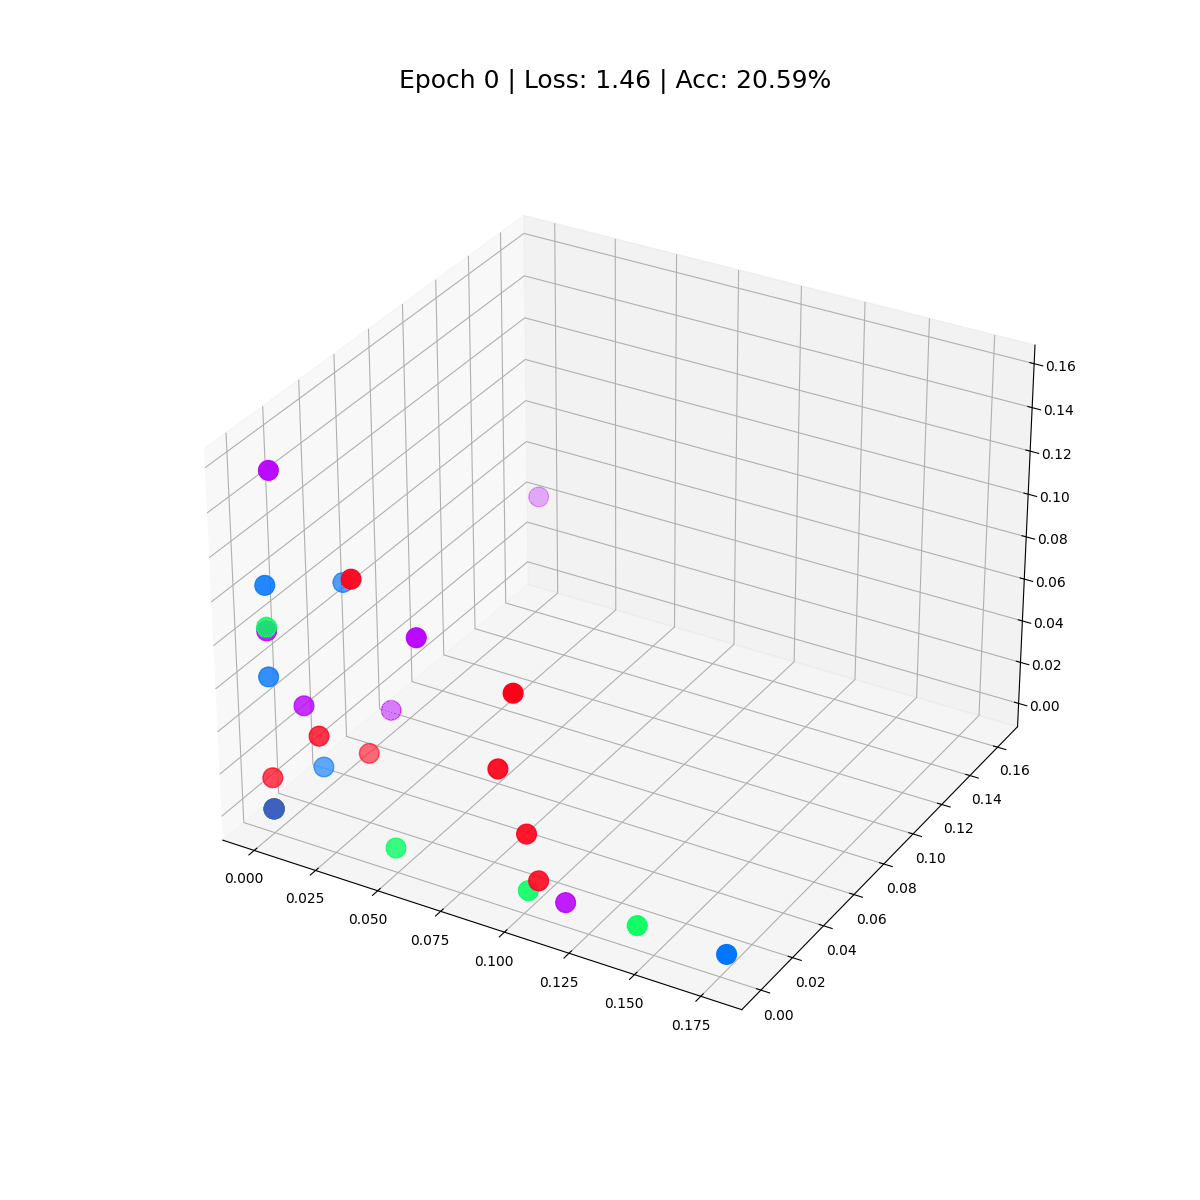

In [14]:
from IPython.display import Image
Image("embeddings_3d_animation.gif")